# 1. Install deps

In [ ]:
import sys
import os

if 'google.colab' in sys.modules:
    if not os.path.exists('/content/NLP'):
        !git clone -b lab-06 https://github.com/AndrianaNahirna/NLP.git

    %cd /content/NLP

    !pip install -r requirements.txt -q
    !git fetch origin
    !git reset --hard origin/lab-06

    sys.path.append('/content/NLP')

print("Середовище налаштовано.")

Cloning into 'NLP'...
remote: Enumerating objects: 210, done.
remote: Counting objects: 100% (210/210), done.
remote: Compressing objects: 100% (123/123), done.
remote: Total 210 (delta 74), reused 191 (delta 57), pack-reused 0 (from 0)
Receiving objects: 100% (210/210), 2.00 MiB | 4.52 MiB/s, done.
Resolving deltas: 100% (74/74), done.
/content/NLP
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 990.1/990.1 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 21.1 MB/s eta 0:00:00
HEAD is now at 913138f finish lab5
Середовище налаштовано.


# 2. Data access

In [2]:
import pandas as pd

if 'google.colab' in sys.modules:
    FOLDER_ID = '1Z4ko8PYcLJOnnU98T6MTXLVYHnpMkHVK'

    # Завантаження датасету
    os.makedirs('/content/NLP/data', exist_ok=True)
    !gdown --folder https://drive.google.com/drive/folders/{FOLDER_ID} -O /content/NLP/data/

    import glob
    csv_files = glob.glob('/content/NLP/data/**/processed_v3_lemma.csv', recursive=True)

    if csv_files:
        data_path = csv_files[0]
        df = pd.read_csv(data_path)
        print(f"Датасет завантажено. Кількість рядків: {len(df)}")
    else:
        print("Файл processed_v3_lemma.csv не знайдено.")
else:
    # Локальний шлях
    df = pd.read_csv('../data/processed_v3_lemma.csv')

Retrieving folder contents
Processing file 12MwPw-0rT5kZoMFme6erhb4NeBsQxsoECoQzPuAqWcI processed_v2
Processing file 17odn4ukdHLvZKqqUuaTNPuHX66Aal-zk processed_v2.csv
Processing file 1gMJmeUiP3HXGR4P3F3Gq-eWhKkPxAbnw processed_v3_lemma.csv
Processing file 1tVj7OaRkYqaoVtmDGgDxUQ8nkDUvy7W7 raw.csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=12MwPw-0rT5kZoMFme6erhb4NeBsQxsoECoQzPuAqWcI
From (redirected): https://docs.google.com/spreadsheets/d/12MwPw-0rT5kZoMFme6erhb4NeBsQxsoECoQzPuAqWcI/export?format=xlsx
To: /content/NLP/data/NLP_datasets/processed_v2
1.60MB [00:00, 7.01MB/s]
Downloading...
From: https://drive.google.com/uc?id=17odn4ukdHLvZKqqUuaTNPuHX66Aal-zk
To: /content/NLP/data/NLP_datasets/processed_v2.csv
100% 5.67M/5.67M [00:00<00:00, 48.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1gMJmeUiP3HXGR4P3F3Gq-eWhKkPxAbnw
To: /content/NLP/data/NLP_da

# 3. Load split

In [3]:
import pandas as pd

df = pd.read_csv("data/NLP_datasets/processed_v3_lemma.csv")
df['text_id'] = df.index.astype(str)

# Функція для зчитування ID з txt файлів
def load_ids(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        return [line.strip() for line in f if line.strip()]

train_ids = load_ids("sentiment/data/sample/splits_train_ids.txt")
val_ids = load_ids("sentiment/data/sample/splits_val_ids.txt")
test_ids = load_ids("sentiment/data/sample/splits_test_ids.txt")

df_train = df[df['text_id'].isin(train_ids)]
df_val = df[df['text_id'].isin(val_ids)]
df_test = df[df['text_id'].isin(test_ids)]

print(f"Загальний розмір датасету: {len(df)}")
print(f"Розмір train: {len(df_train)}")
print(f"Розмір val: {len(df_val)}")
print(f"Розмір test: {len(df_test)}")

# для Baseline 1
X_train_proc = df_train['processed_text']
X_val_proc = df_val['processed_text']
X_test_proc = df_test['processed_text']

# для Baseline 2 та 3
X_train_lem = df_train['lemma_text']
X_val_lem = df_val['lemma_text']
X_test_lem = df_test['lemma_text']

# Мітки класів
y_train = df_train['target']
y_val = df_val['target']
y_test = df_test['target']

Загальний розмір датасету: 3034
Розмір train: 2427
Розмір val: 303
Розмір test: 304


# 4. Baseline 1
# 5. Baseline 2
# + Baseline 3
# 6. Metrics comparison

In [4]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Baseline 1: Звичайний текст (processed_v2)
pipe_b1 = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer="word", ngram_range=(1, 2), sublinear_tf=True)),
    ('logreg', LogisticRegression(max_iter=500, random_state=42))
])
pipe_b1.fit(X_train_proc, y_train)
y_pred_b1 = pipe_b1.predict(X_test_proc)

# Baseline 2: Лематизований текст (lemma_text)
pipe_b2 = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer="word", ngram_range=(1, 2), sublinear_tf=True)),
    ('logreg', LogisticRegression(max_iter=500, random_state=42))
])
pipe_b2.fit(X_train_lem, y_train)
y_pred_b2 = pipe_b2.predict(X_test_lem)

# Baseline 3: Лематизований текст + Балансування класів
pipe_b3 = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer="word", ngram_range=(1, 2), sublinear_tf=True)),
    ('logreg', LogisticRegression(max_iter=500, class_weight='balanced', random_state=42))
])
pipe_b3.fit(X_train_lem, y_train)
y_pred_b3 = pipe_b3.predict(X_test_lem)

print("Порівняння Baseline моделей")
print(f"1. processed_v2: Accuracy = {accuracy_score(y_test, y_pred_b1):.4f}, Macro-F1 = {f1_score(y_test, y_pred_b1, average='macro'):.4f}")
print(f"2. lemma_text:   Accuracy = {accuracy_score(y_test, y_pred_b2):.4f}, Macro-F1 = {f1_score(y_test, y_pred_b2, average='macro'):.4f}")
print(f"3. lemma_text + Balanced:   Accuracy = {accuracy_score(y_test, y_pred_b3):.4f}, Macro-F1 = {f1_score(y_test, y_pred_b3, average='macro'):.4f}")

Порівняння Baseline моделей
1. processed_v2: Accuracy = 0.8092, Macro-F1 = 0.7597
2. lemma_text:   Accuracy = 0.8059, Macro-F1 = 0.7582
3. lemma_text + Balanced:   Accuracy = 0.8553, Macro-F1 = 0.8407


In [5]:
print("Classification Report для lemma_text + Balanced")
print(classification_report(y_test, y_pred_b3))

Classification Report для lemma_text + Balanced
              precision    recall  f1-score   support

    negative       0.87      0.91      0.89       193
    positive       0.83      0.76      0.79       111

    accuracy                           0.86       304
   macro avg       0.85      0.83      0.84       304
weighted avg       0.85      0.86      0.85       304



# 7. Confusion matrix


Confusion Matrix для lemma_text + Balanced


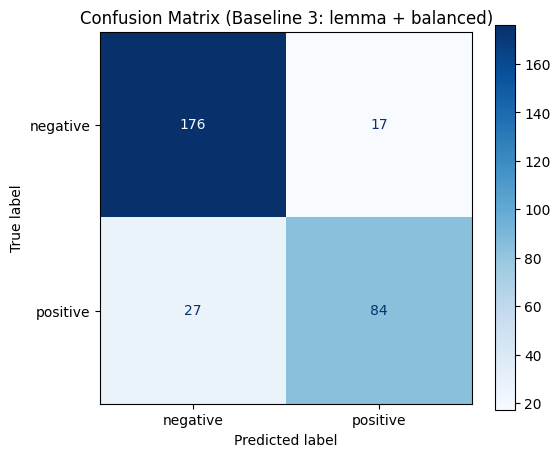

In [6]:
import matplotlib.pyplot as plt

print("Confusion Matrix для lemma_text + Balanced")
cm = confusion_matrix(y_test, y_pred_b3, labels=pipe_b3.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipe_b3.classes_)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title('Confusion Matrix (Baseline 3: lemma + balanced)')
plt.show()

# 8. Top features

In [7]:
import numpy as np

print("Top 10 Features для кожного класу")

vectorizer = pipe_b3.named_steps['tfidf']
classifier = pipe_b3.named_steps['logreg']

feature_names = np.array(vectorizer.get_feature_names_out())

coefs = classifier.coef_[0]
sorted_coef_indices = coefs.argsort()

top_negative_indices = sorted_coef_indices[:10]
top_negative_features = feature_names[top_negative_indices]
top_negative_coefs = coefs[top_negative_indices]

print("\nТоп-10 ознак для класу NEGATIVE:")
for feat, coef in zip(top_negative_features, top_negative_coefs):
    print(f"{feat}: {coef:.4f}")

top_positive_indices = sorted_coef_indices[-10:][::-1]
top_positive_features = feature_names[top_positive_indices]
top_positive_coefs = coefs[top_positive_indices]

print("\nТоп-10 ознак для класу POSITIVE:")
for feat, coef in zip(top_positive_features, top_positive_coefs):
    print(f"{feat}: {coef:.4f}")

Top 10 Features для кожного класу

Топ-10 ознак для класу NEGATIVE:
не рекомендувати: -2.0905
ніхто: -1.8678
вони: -1.7519
ніхто не: -1.5905
не: -1.3790
центр: -1.3544
відправити: -1.3394
сказати: -1.2244
мати: -1.2218
гроші: -1.1946

Топ-10 ознак для класу POSITIVE:
задоволений: 3.0018
дуже: 2.5015
все: 2.2210
спасибі: 1.8873
завжди: 1.7342
швидко: 1.7082
весь: 1.5319
хороший: 1.5233
цитрус: 1.4636
ціна: 1.3906


Аналіз Top Features:
* Загалом ознаки виглядають дуже логічно. Для класу NEGATIVE модель орієнтується на заперечення ("не рекомендувати", "ніхто не") та проблемні слова ("гроші", "відправити"). Для класу POSITIVE преважають слова-подяки ("спасибі", "задоволений") та позитивні характеристики ("швидко", "хороший", "ціна").
* Критичне спостереження: У топ-10 позитивних фіч потрапило слово "цитрус". Це явний leakage (витік даних). Очевидно, що в датасеті переважають позитивні відгуки про цей конкретний магазин. Модель запам'ятала цю кореляцію замість того, щоб вчити семантику. Це серйозний ризик (drift), оскільки при подачі відгуку про інший магазин модель може помилитися. В майбутньому потрібно або додати назви магазинів у stop-words, або використовувати Named Entity Recognition (NER), щоб маскувати назви компаній перед класифікацією.

# 9. Error analysis

In [11]:
import pandas as pd

print("Error Analysis\n")

error_df = pd.DataFrame({
    'text_id': df_test['text_id'],
    'text': df_test['processed_text'],
    'gold_label': y_test,
    'predicted_label': y_pred_b3
})

errors = error_df[error_df['gold_label'] != error_df['predicted_label']]

print(f"Всього знайдено помилок на test: {len(errors)}")

sample_errors = errors.sample(n=10, random_state=42)

for idx, row in sample_errors.iterrows():
    print(f"Text ID: {row['text_id']}")
    print(f"Text: {row['text']}")
    print(f"Gold: {row['gold_label']} | Predicted: {row['predicted_label']}")
    print("-" * 200)

Error Analysis

Всього знайдено помилок на test: 44
Text ID: 2679
Text: Мав необережність придбати установочний комплект на куллер Zаlmаn. Провіряти не став так як ціна невелика і по суті провіряти там нічого. Забрав. Так вот ні і тут умудрились напартачити пів комлекта просто немає одна установочна пластина. Ну кому ж ті болтики з планками потрібні то без пластини. Їх просто не положили і все. При розмові просять відправти на сервісний центр шоб він там балтався 14 днів, щоб дали заключення шо він не комплектний. І упакували якость дивно в коробку де таких двадцять можна положити і ще місце залишиться. Це я ще змовчав про доставку тиждень ціли доставляли два дрібних товара. Фото прикріплюю.
Gold: positive | Predicted: negative
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Text ID: 1618
Text: Зламали навушники через 2 місяці після пр

Error Analysis

Text ID: 2679
Text: Мав необережність придбати... [весь текст про відсутні деталі, погану упаковку і довгу доставку]
Gold: positive | Predicted: negative
Коментар: Шумна розмітка (Noisy label). Текст на 100% складається з негативу (скарги на комплект, жахливу упаковку та повільну доставку). Модель абсолютно правильно розпізнала негативну тональність, але в датасеті стоїть хибна мітка "positive" (ймовірно, помилка користувача при виставленні оцінки).

Text ID: 1618
Text: Зламали навушники через 2 місяці... [скарга на сервіс, 31 день очікування, обман, погрози захистом прав споживачів]
Gold: positive | Predicted: negative
Коментар: Шумна розмітка. Аналогічна ситуація. Текст описує жахливий досвід гарантійного ремонту та обман з боку менеджерів. Модель правильно вловила негатив, незважаючи на хибну мітку "positive" в золотому стандарті.

Text ID: 1698
Text: Я от не зрозумію шановна Розетка... [скарга на відсутність гарантії, ігнорування] ...Після того як з мною зв'язалися, питання вирішилося оперативно протягом години!
Gold: positive | Predicted: negative
Коментар: Overlap класів (змішана тональність). 90% тексту — це гнівна скарга з великою кількістю негативних маркерів ("некомпетентність", "нісенітниці"). Однак в останньому реченні проблема вирішується. Базова TF-IDF модель просто сумує ваги слів, тому сильний негатив на початку "переважив" позитивний фінал.

Text ID: 2635
Text: Замовлення і видача товару пройшла без проблем... Але от якщо хочеш повернути товар... [величезна скарга на процес повернення]
Gold: positive | Predicted: negative
Коментар: Шумна розмітка / Overlap класів. Відгук починається позитивно ("пройшла без проблем"), але далі йде детальна скарга на жахливий сервіс повернення. Користувач, очевидно, оцінив сам товар високо (тому Gold=positive), але текст описує негативний досвід. Модель спрацювала логічно.

Text ID: 2430
Text: Хочу висловити подяку персоналу... [але далі йде опис зламаного телефону, довгого ремонту, відсутності документів та підміни IMEI]
Gold: positive | Predicted: negative
Коментар: Overlap класів / Сарказм. Відгук починається з подяки співробітнику, що дало моделі сильні позитивні фічі, але суть тексту — це серйозна скарга на підроблений/зламаний пристрій та порушення прав споживача.

Text ID: 2750
Text: Розетка "втрачаэ позиціі"... [скарги на подвійну оплату доставки, порвану коробку] Такі промахи неприпустимі!!
Gold: positive | Predicted: negative
Коментар: Шумна розмітка. Суцільний негатив, обурення сервісом та станом товару. Мітка "positive" у датасеті є абсолютно помилковою. Модель тут права.

Text ID: 239
Text: Все ніби добре, і вибір товару, і сайт зручний... Але є одне велике але!! це доставка... Вкрай незадоволений.
Gold: negative | Predicted: positive
Коментар: Overlap класів / Бракує контексту. Класична проблема для лінійних моделей: текст починається з  позитивних слів ("добре", "зручний"), які збивають модель з пантелику. Модель не розуміє контекстного переходу після слова "Але", яке повністю змінює тональність на негативну.

Text ID: 999
Text: Давно користуюся послугами... було все чудово, але... [далі йде опис затримки і розчарування]
Gold: negative | Predicted: positive
Коментар: Overlap класів. Ситуація, ідентична до попередньої. Слова "чудово" та "давно користуюся" перетягнули ваги на користь позитивного класу, і модель проігнорувала розчарування в кінці тексту.

Text ID: 850
Text: Купив корпус... Корпус непоганий, бп неробочий... Дуже засмучений ситуацією...
Gold: negative | Predicted: positive
Коментар: Overlap класів. Змішаний відгук, де одна частина товару хороша ("непоганий"), а інша — зламана. Модель побачила слова "подарунок", "непоганий", "перевага" і помилково класифікувала текст як позитивний, пропустивши суть скарги.

Text ID: 95
Text: ...Загалом навушники самі по собі відмінні... але ваші 5000 грн просто викинуті на вітер [через жахливий сервіс].
Gold: positive | Predicted: negative
Коментар: Шумна розмітка / Overlap класів. Користувач хвалить навушники, але жорстко критикує сервіс. Модель спіймала фразу "гроші на вітер" і класифікувала текст як негативний. Оцінка "positive" у датасеті, швидше за все, стосується лише якості звуку, а не загального враження.

**Висновок:**
За результатами ручного розбору можна виділити дві ключові категорії помилок. Найчастішою проблемою виявилася шумна розмітка (noisy labels): у багатьох випадках користувачі залишали абсолютно гнівні відгуки про сервіс чи доставку, але виставляли високу оцінку (positive), через що модель передбачала тональність правильніше, ніж сам золотий стандарт. Друга типова проблема — це overlap класів, коли відгук починається з похвали ("все було чудово"), але після слова "але" переходить у скаргу. Лінійна модель на базі TF-IDF просто підсумовує ваги і не вловлює зміну контексту. Першим кроком для покращення системи має стати чистка датасету від шумної розмітки та видалення назв конкретних брендів (щоб уникнути leakage). Ймовірно, найбільший приріст у вирішенні проблеми "overlap класів" дасть перехід від TF-IDF до ембеддингів або трансформерних моделей (наприклад, BERT), які здатні розуміти послідовність слів і семантичні розвороти в тексті.

# 10. Generate docs/audit_summary_lab6.md

In [10]:
import os
from sklearn.metrics import accuracy_score, f1_score

os.makedirs('sentiment/docs', exist_ok=True)

markdown_content = f"""# Audit Summary - Lab 6

**1. Яка classification-підзадача:**
Бінарна класифікація тональності відгуків (positive vs negative) на основі відкритих даних з українських маркетплейсів.

**2. Який split використано:**
Використано готові зафіксовані спліти з Лабораторної роботи №5 (збережені у txt-файлах).
Train: {len(X_train_lem)} прикладів, Val: {len(X_val_lem)} прикладів, Test: {len(X_test_lem)} прикладів.

**3. Baseline 1 (processed_v2 + Logistic Regression):**
- Accuracy: {accuracy_score(y_test, y_pred_b1):.4f}
- Macro-F1: {f1_score(y_test, y_pred_b1, average='macro'):.4f}

**4. Baseline 2 (lemma_text + Logistic Regression):**
- Accuracy: {accuracy_score(y_test, y_pred_b2):.4f}
- Macro-F1: {f1_score(y_test, y_pred_b2, average='macro'):.4f}

**5. Baseline 3 / Найкращий (lemma_text + Balanced Logistic Regression):**
- Accuracy: {accuracy_score(y_test, y_pred_b3):.4f}
- Macro-F1: {f1_score(y_test, y_pred_b3, average='macro'):.4f}

**6. Чи був приріст і від чого:**
Так, приріст метрики Macro-F1 був суттєвим у Baseline 3 (з ~0.759 до ~0.840). Він відбувся виключно завдяки додаванню параметра `class_weight='balanced'`, який дозволив моделі ефективніше розпізнавати менший клас (negative). Використання лише лематизації (Baseline 2) порівняно з базовим текстом (Baseline 1) суттєвого приросту метрик не дало.

**7. 3 найтиповіші категорії помилок:**
1. **Шумна розмітка (Noisy labels):** у тестовій вибірці присутні гнівні відгуки про жахливий сервіс, яким користувачі випадково або помилково поставили позитивну оцінку. Модель розпізнає негатив правильно, але "золотий стандарт" хибний.
2. **Overlap класів (змішана тональність):** відгук містить і похвалу, і скаргу. Лінійна модель (TF-IDF) просто підсумовує ваги слів і часто не вловлює зміну контексту (наприклад, після слова "але").
3. **Брак контексту:** дуже короткі тексти без яскраво виражених маркерів тональності.

**8. Що фіксити далі:**
- Очистити датасет від явно хибної розмітки (noisy labels).
- Видалити з тексту назви конкретних брендів та магазинів (наприклад, слово "цитрус", яке потрапило в топ-фічі), оскільки вони створюють витік даних (leakage) і змушують модель запам'ятовувати кореляцію бренду з тональністю, а не семантику.
- Для вирішення проблеми "overlap класів" доцільно в майбутньому перейти від TF-IDF до ембеддингів або архітектур трансформерів (наприклад, BERT), які здатні розуміти послідовність тексту.
"""

with open('sentiment/docs/audit_summary_lab6.md', 'w', encoding='utf-8') as f:
    f.write(markdown_content)

print("Файл docs/audit_summary_lab6.md згенеровано.")

Файл docs/audit_summary_lab6.md згенеровано.
